### Import Libraries

In [85]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [87]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LEN    = 30    # ventana de 30 días previos
BATCH_SIZE = 64
EPOCHS     = 60
LR         = 1e-3

print(f'PyTorch: {torch.__version__} | Device: {DEVICE}')

PyTorch: 2.10.0+cpu | Device: cpu


### Cargamos dataset

In [88]:
# Use KAGGLE_API_TOKEN for the new KGAT tokens
os.environ["KAGGLE_API_TOKEN"] = "KGAT_c0f315263658f110bd20f8d20415687a"

In [89]:
path = kagglehub.competition_download('store-sales-time-series-forecasting')
print("Path to competition files:", path)

import os
print("Archivos disponibles:", os.listdir(path))

train_df  = pd.read_csv(f'{path}/train.csv',          parse_dates=['date'])
stores_df = pd.read_csv(f'{path}/stores.csv')
oil_df    = pd.read_csv(f'{path}/oil.csv',            parse_dates=['date'])
hol_df    = pd.read_csv(f'{path}/holidays_events.csv',parse_dates=['date'])

print(f'\ntrain    : {train_df.shape}')
print(f'stores   : {stores_df.shape}')
print(f'oil      : {oil_df.shape}')
print(f'holidays : {hol_df.shape}')
print(train_df.head(3))


Path to competition files: /root/.cache/kagglehub/competitions/store-sales-time-series-forecasting
Archivos disponibles: ['sample_submission.csv', 'oil.csv', 'holidays_events.csv', 'transactions.csv', 'test.csv', 'train.csv', 'stores.csv']

train    : (3000888, 6)
stores   : (54, 5)
oil      : (1218, 2)
holidays : (350, 6)
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0


In [90]:
FAMILY = 'GROCERY I'
df = train_df[train_df['family'] == FAMILY].copy()
print(f'\nRegistros para {FAMILY}: {df.shape}')

# ── Merge con stores (tipo de tienda, ciudad, estado, cluster) 
df = df.merge(stores_df, on='store_nbr', how='left')

# ── Merge con precio del petróleo ────────────────────────────
oil_df = oil_df.rename(columns={'dcoilwtico': 'oil_price'})
oil_df['oil_price'] = oil_df['oil_price'].ffill().bfill()
df = df.merge(oil_df, on='date', how='left')
# Algunas fechas en df no existen en oil_df -> quedan NaN. Las propagamos.
df['oil_price'] = df['oil_price'].ffill().bfill()

# ── Festivos nacionales ───────────────────────────────────────
national_hol = hol_df[
    (hol_df['locale'] == 'National') &
    (hol_df['type'].isin(['Holiday', 'Transfer']))
][['date']].drop_duplicates()
national_hol['is_holiday'] = 1
df = df.merge(national_hol, on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

# ── Features temporales ───────────────────────────────────────
df['dayofweek'] = df['date'].dt.dayofweek      # 0=lunes
df['month']     = df['date'].dt.month
df['year']      = df['date'].dt.year
df['dayofyear'] = df['date'].dt.dayofyear
df['quarter']   = df['date'].dt.quarter

# ── Target: log1p para estabilizar varianza ──────────────────
# log1p porque las ventas tienen distribución muy sesgada
df['sales_log'] = np.log1p(df['sales'])

print(f'\nColumnas finales: {df.columns.tolist()}')
print(df[['date','store_nbr','sales','sales_log','type','city','oil_price','is_holiday']].head(5))


Registros para GROCERY I: (90936, 6)

Columnas finales: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_holiday', 'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'sales_log']
        date  store_nbr  sales  sales_log type       city  oil_price  \
0 2013-01-01          1    0.0        0.0    D      Quito      93.14   
1 2013-01-01         10    0.0        0.0    C      Quito      93.14   
2 2013-01-01         11    0.0        0.0    B    Cayambe      93.14   
3 2013-01-01         12    0.0        0.0    C  Latacunga      93.14   
4 2013-01-01         13    0.0        0.0    C  Latacunga      93.14   

   is_holiday  
0           1  
1           1  
2           1  
3           1  
4           1  


### EDA

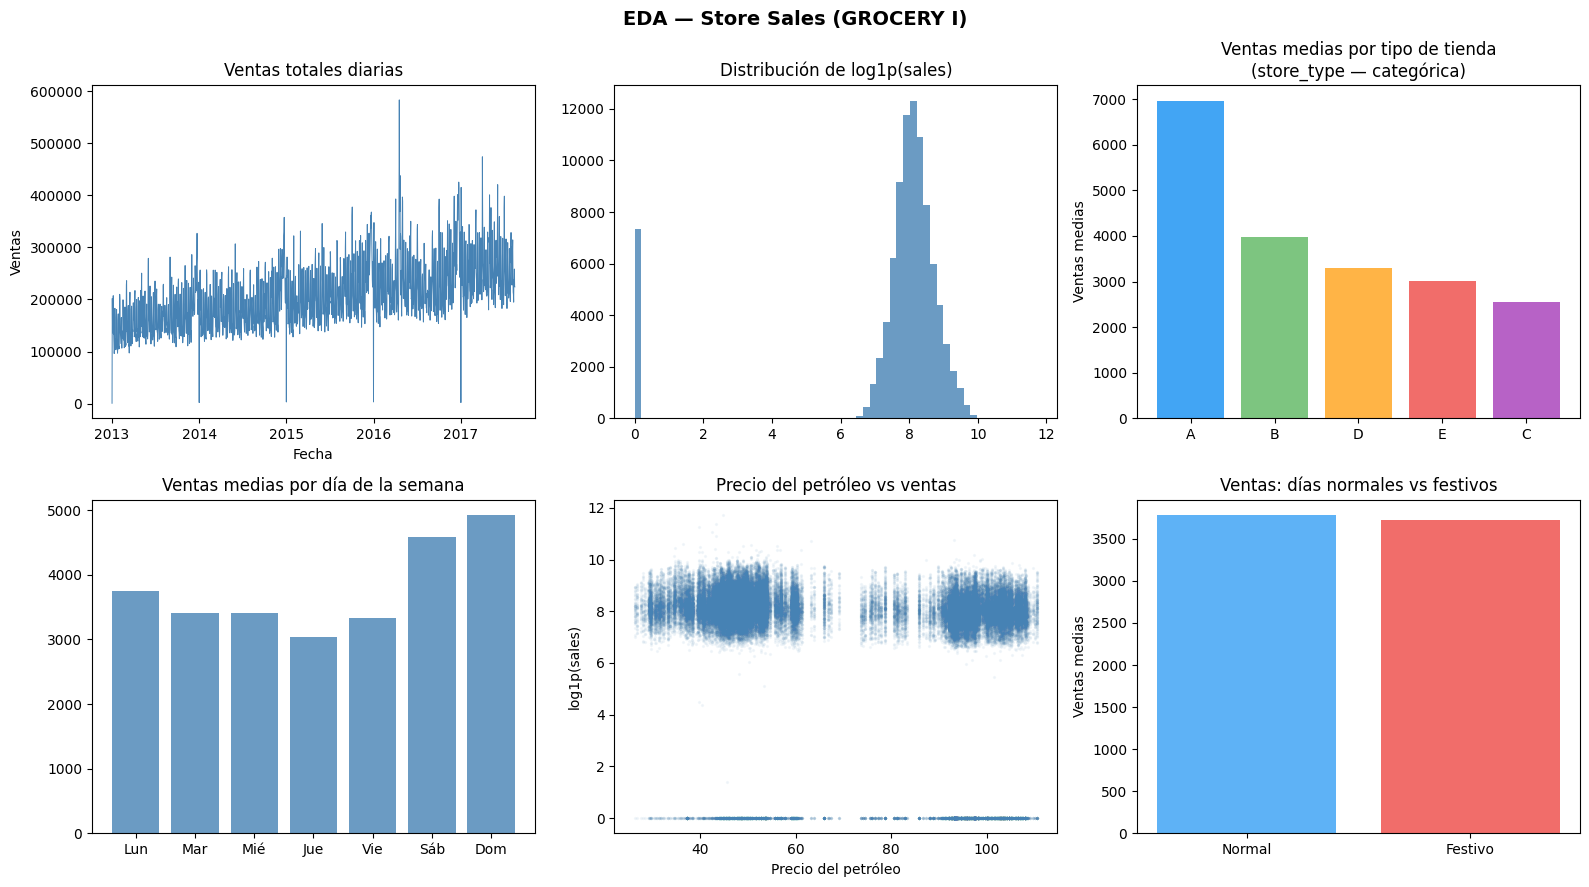

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Store Sales (GROCERY I)', fontsize=14, fontweight='bold')

# Serie de tiempo de ventas totales diarias
daily = df.groupby('date')['sales'].sum().reset_index()
axes[0,0].plot(daily['date'], daily['sales'], lw=0.7, color='steelblue')
axes[0,0].set_title('Ventas totales diarias')
axes[0,0].set_xlabel('Fecha'); axes[0,0].set_ylabel('Ventas')

# Distribución del target (log)
axes[0,1].hist(df['sales_log'], bins=60, color='steelblue', alpha=0.8, ec='white')
axes[0,1].set_title('Distribución de log1p(sales)')

# Ventas por tipo de tienda (variable categórica clave)
tm = df.groupby('type')['sales'].mean().sort_values(ascending=False)
axes[0,2].bar(tm.index, tm.values,
              color=['#2196F3','#66BB6A','#FFA726','#EF5350','#AB47BC'],
              alpha=0.85)
axes[0,2].set_title('Ventas medias por tipo de tienda\n(store_type — categórica)')
axes[0,2].set_ylabel('Ventas medias')

# Ventas por día de la semana
dm = df.groupby('dayofweek')['sales'].mean()
days = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
axes[1,0].bar(days, dm.values, color='steelblue', alpha=0.8)
axes[1,0].set_title('Ventas medias por día de la semana')

# Impacto del precio del petróleo
axes[1,1].scatter(df['oil_price'], df['sales_log'], alpha=0.05, s=2, color='steelblue')
axes[1,1].set_xlabel('Precio del petróleo'); axes[1,1].set_ylabel('log1p(sales)')
axes[1,1].set_title('Precio del petróleo vs ventas')

# Ventas en festivos vs días normales
hol_comp = df.groupby('is_holiday')['sales'].mean()
axes[1,2].bar(['Normal','Festivo'], hol_comp.values,
              color=['#42A5F5','#EF5350'], alpha=0.85)
axes[1,2].set_title('Ventas: días normales vs festivos')
axes[1,2].set_ylabel('Ventas medias')

plt.tight_layout(); plt.show()


In [92]:
daily_agg = df.groupby('date').agg(
    sales      = ('sales',      'sum'),
    oil_price  = ('oil_price',  'first'),
    is_holiday = ('is_holiday', 'max'),
    dayofweek  = ('dayofweek',  'first'),
    month      = ('month',      'first'),
    quarter    = ('quarter',    'first'),
    year       = ('year',       'first'),
    onpromotion= ('onpromotion','sum'),
).reset_index().sort_values('date').reset_index(drop=True)

# Target correcto: log1p de la suma real de ventas

daily_agg['sales_log'] = np.log1p(daily_agg['sales'])
# Normalizar año a 0/1/2/3
daily_agg['year_idx'] = daily_agg['year'] - daily_agg['year'].min()

print(f'Serie diaria agregada: {daily_agg.shape}')
print(daily_agg.head(3))

Serie diaria agregada: (1684, 11)
        date     sales  oil_price  is_holiday  dayofweek  month  quarter  \
0 2013-01-01     700.0      93.14           1          1      1        1   
1 2013-01-02  202020.0      93.14           0          2      1        1   
2 2013-01-03  144878.0      92.97           0          3      1        1   

   year  onpromotion  sales_log  year_idx  
0  2013            0   6.552508         0  
1  2013            0  12.216127         0  
2  2013            0  11.883654         0  


In [93]:
# ── Definición de columnas ────────────────────────────────────
# Categóricas con embeddings
CAT_COLS = ['dayofweek', 'month', 'quarter']
# Numéricas escaladas
NUM_COLS = ['oil_price', 'is_holiday', 'onpromotion', 'year_idx']
TARGET   = 'sales_log'

# Configuración de embeddings
CAT_DIMS = {}
for col in CAT_COLS:
    n_unique      = int(daily_agg[col].max()) + 1
    emb_dim       = min(50, max(2, (n_unique + 1) // 2))
    CAT_DIMS[col] = (n_unique, emb_dim)

print('\nEmbeddings:')
for col, (v, d) in CAT_DIMS.items():
    print(f'  {col:12s}: vocab={v:3d}  emb_dim={d}')


Embeddings:
  dayofweek   : vocab=  7  emb_dim=4
  month       : vocab= 13  emb_dim=7
  quarter     : vocab=  5  emb_dim=3


In [94]:
# ── Scalers ───────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

df_num = daily_agg[NUM_COLS].values.astype(np.float32)
df_cat = daily_agg[CAT_COLS].values.astype(np.int64)
df_tgt = daily_agg[TARGET].values.astype(np.float32).reshape(-1, 1)

n       = len(daily_agg)
n_train = int(n * 0.80)
n_val   = int(n * 0.90)

X_num_tr  = scaler_X.fit_transform(df_num[:n_train])
X_num_va  = scaler_X.transform(df_num[n_train:n_val])
X_num_te  = scaler_X.transform(df_num[n_val:])
X_num_all = np.vstack([X_num_tr, X_num_va, X_num_te])

scaler_y.fit(df_tgt[:n_train])
y_all = scaler_y.transform(df_tgt)

NUM_FEATS = len(NUM_COLS)
INPUT_DIM = NUM_FEATS + sum(d for _, d in CAT_DIMS.values())

print(f'\nSplit — train: {n_train:,} | val: {n_val-n_train:,} | test: {n-n_val:,}')
print(f'INPUT_DIM: {INPUT_DIM}  (numéricas={NUM_FEATS} + embeddings={INPUT_DIM-NUM_FEATS})')


Split — train: 1,347 | val: 168 | test: 169
INPUT_DIM: 18  (numéricas=4 + embeddings=14)


In [95]:
# ── Dataset con ventana deslizante ────────────────────────────
class SalesDataset(Dataset):
    def __init__(self, X_num, X_cat, y, seq_len=SEQ_LEN):
        self.Xn  = torch.tensor(X_num, dtype=torch.float32)
        self.Xc  = torch.tensor(X_cat, dtype=torch.long)
        self.y   = torch.tensor(y,     dtype=torch.float32)
        self.sl  = seq_len

    def __len__(self):
        return len(self.Xn) - self.sl

    def __getitem__(self, i):
        return self.Xn[i:i+self.sl], self.Xc[i:i+self.sl], self.y[i+self.sl]


train_loader = DataLoader(
    SalesDataset(X_num_all[:n_train], df_cat[:n_train], y_all[:n_train]),
    batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(
    SalesDataset(X_num_all[n_train:n_val], df_cat[n_train:n_val], y_all[n_train:n_val]),
    batch_size=BATCH_SIZE)
test_loader  = DataLoader(
    SalesDataset(X_num_all[n_val:], df_cat[n_val:], y_all[n_val:]),
    batch_size=BATCH_SIZE)

xn, xc, yb = next(iter(train_loader))
print(f'\nBatch — x_num: {xn.shape} | x_cat: {xc.shape} | y: {yb.shape}')



Batch — x_num: torch.Size([64, 30, 4]) | x_cat: torch.Size([64, 30, 3]) | y: torch.Size([64, 1])


### Arquitecturas empleadas

In [96]:
class CategoricalEmbedder(nn.Module):
    """
    Embeddings aprendibles para variables categóricas concatenados
    con variables numéricas.
    Salida: (batch, seq, NUM_FEATS + sum(emb_dims))
    """
    def __init__(self, cat_dims, num_feats, dropout=0.1):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab, emb_dim)
            for vocab, emb_dim in cat_dims.values()
        ])
        self.out_dim = num_feats + sum(d for _, d in cat_dims.values())
        self.drop    = nn.Dropout(dropout)

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[..., i]) for i, emb in enumerate(self.embeddings)]
        return self.drop(torch.cat([x_num] + embs, dim=-1))

In [97]:
class BaselineLinear(nn.Module):
    """
    Aplana la ventana temporal y aplica capas lineales.
    Sin capacidad de modelar dependencias temporales.
    Establece el piso mínimo de rendimiento.
    """
    def __init__(self, seq_len, input_dim, hidden=128):
        super().__init__()
        self.embedder = CategoricalEmbedder(CAT_DIMS, NUM_FEATS)
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_num, x_cat):
        return self.net(self.embedder(x_num, x_cat))


In [98]:
class CNN1DModel(nn.Module):
    """
    Convoluciones paralelas con kernels 3/5/7 para capturar
    patrones locales de distintas escalas temporales:
    variaciones semanales, quincenales y mensuales.
    """
    def __init__(self, input_dim, n_filters=64, dropout=0.2):
        super().__init__()
        self.embedder = CategoricalEmbedder(CAT_DIMS, NUM_FEATS)
        self.conv3 = nn.Sequential(
            nn.Conv1d(input_dim, n_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(n_filters), nn.ReLU())
        self.conv5 = nn.Sequential(
            nn.Conv1d(input_dim, n_filters, kernel_size=5, padding=2),
            nn.BatchNorm1d(n_filters), nn.ReLU())
        self.conv7 = nn.Sequential(
            nn.Conv1d(input_dim, n_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(n_filters), nn.ReLU())
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(n_filters * 3, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x_num, x_cat):
        x = self.embedder(x_num, x_cat).permute(0, 2, 1)  # (B,D,T)
        return self.head(
            torch.cat([self.conv3(x), self.conv5(x), self.conv7(x)], 1)
        )


In [99]:
class PositionalEncoding(nn.Module):
    """
    Positional Encoding sinusoidal
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerTimeSeries(nn.Module):
    """
    Transformer Encoder para forecasting de series temporales.

    Arquitectura:
      1. CategoricalEmbedder (numéricas + embeddings categóricos)
      2. Proyección lineal a d_model
      3. Positional Encoding
      4. N capas de Transformer Encoder
         (multi-head self-attention + FFN + LayerNorm + residual)
      5. Global Average Pooling sobre la dimensión temporal
      6. Head de regresión (LayerNorm → Linear → GELU → Dropout → Linear)

    La self-attention captura dependencias de largo plazo
    que las CNN con kernels fijos no pueden modelar.
    """
    def __init__(self, input_dim, d_model=64, nhead=4,
                 num_layers=3, dim_feedforward=256, dropout=0.2):
        super().__init__()
        self.embedder = CategoricalEmbedder(CAT_DIMS, NUM_FEATS, dropout=0.0)

        # Proyección a d_model (si input_dim == d_model es redundante pero consistente)
        self.input_proj = nn.Linear(input_dim, d_model)

        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,       # espera (B, T, D)
            activation="gelu"
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Head de regresión
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat):
        x = self.embedder(x_num, x_cat)   # (B, T, input_dim)
        x = self.input_proj(x)             # (B, T, d_model)
        x = self.pos_encoder(x)            # (B, T, d_model)
        x = self.transformer_encoder(x)    # (B, T, d_model)
        x = x.mean(dim=1)                  # Global Avg Pool → (B, d_model)
        return self.head(x)    # (B,)


In [100]:
print(f'Baseline  : {sum(p.numel() for p in BaselineLinear(SEQ_LEN, INPUT_DIM).parameters()):,} parametros')
print(f'CNN-1D    : {sum(p.numel() for p in CNN1DModel(INPUT_DIM).parameters()):,} parametros')
# Transformer con d_model=64, nhead=4, num_layers=3
transformer_test = TransformerTimeSeries(INPUT_DIM, d_model=64, nhead=4, num_layers=3)
print(f'Transformer: {sum(p.numel() for p in transformer_test.parameters()):,} parametros')


Baseline  : 69,511 parametros
CNN-1D    : 42,823 parametros
Transformer: 159,879 parametros


### Entrenamiento de los modelos

In [101]:
def train_model(model, train_loader, val_loader,
                model_name='Model', epochs=EPOCHS, patience=12):
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)
    criterion = nn.HuberLoss()

    history    = {'train_loss': [], 'val_loss': []}
    best_val   = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xn_b, xc_b, y_b in train_loader:
            xn_b, xc_b, y_b = xn_b.to(DEVICE), xc_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xn_b, xc_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xn_b, xc_b, y_b in val_loader:
                xn_b, xc_b, y_b = xn_b.to(DEVICE), xc_b.to(DEVICE), y_b.to(DEVICE)
                val_losses.append(criterion(model(xn_b, xc_b), y_b).item())

        tr_l = np.mean(train_losses)
        # ── CORRECCIÓN: si val está vacío usar train loss ──────────
        va_l = np.mean(val_losses) if len(val_losses) > 0 else tr_l

        history['train_loss'].append(tr_l)
        history['val_loss'].append(va_l)
        scheduler.step(va_l)

        # Guardar siempre en la primera época para garantizar best_state
        if va_l < best_val or best_state is None:
            best_val   = va_l
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [{model_name}] Época {epoch:3d}/{epochs} | '
                  f'Train: {tr_l:.4f} | Val: {va_l:.4f}')

        if no_improve >= patience:
            print(f'  [{model_name}] Early stopping en época {epoch}')
            break

    model.load_state_dict(best_state)
    print(f'  [{model_name}] Mejor val_loss: {best_val:.4f}\n')
    return model, history

In [102]:
histories = {}

print('='*55 + '\nBASELINE\n' + '='*55)
baseline = BaselineLinear(SEQ_LEN, INPUT_DIM)
baseline, histories['Baseline'] = train_model(
    baseline, train_loader, val_loader, 'Baseline')

print('='*55 + '\nCNN-1D\n' + '='*55)
cnn_model = CNN1DModel(INPUT_DIM)
cnn_model, histories['CNN-1D'] = train_model(
    cnn_model, train_loader, val_loader, 'CNN-1D')

print('='*55 + '\nTRANSFORMER\n' + '='*55)
transformer = TransformerTimeSeries(INPUT_DIM, d_model=64, nhead=4, num_layers=3)
transformer, histories['Transformer'] = train_model(
    transformer, train_loader, val_loader, 'Transformer')


BASELINE
  [Baseline] Época   1/60 | Train: 0.1412 | Val: 0.1405
  [Baseline] Época  10/60 | Train: 0.0565 | Val: 0.1346
  [Baseline] Época  20/60 | Train: 0.0425 | Val: 0.1453
  [Baseline] Early stopping en época 23
  [Baseline] Mejor val_loss: 0.1260

CNN-1D
  [CNN-1D] Época   1/60 | Train: 0.2177 | Val: 0.2284
  [CNN-1D] Época  10/60 | Train: 0.1292 | Val: 0.1676
  [CNN-1D] Época  20/60 | Train: 0.1045 | Val: 0.1502
  [CNN-1D] Época  30/60 | Train: 0.0820 | Val: 0.1575
  [CNN-1D] Early stopping en época 33
  [CNN-1D] Mejor val_loss: 0.1459

TRANSFORMER
  [Transformer] Época   1/60 | Train: 0.2313 | Val: 0.2871
  [Transformer] Época  10/60 | Train: 0.1048 | Val: 0.1733
  [Transformer] Época  20/60 | Train: 0.0753 | Val: 0.1416
  [Transformer] Época  30/60 | Train: 0.0655 | Val: 0.1448
  [Transformer] Early stopping en época 33
  [Transformer] Mejor val_loss: 0.1362



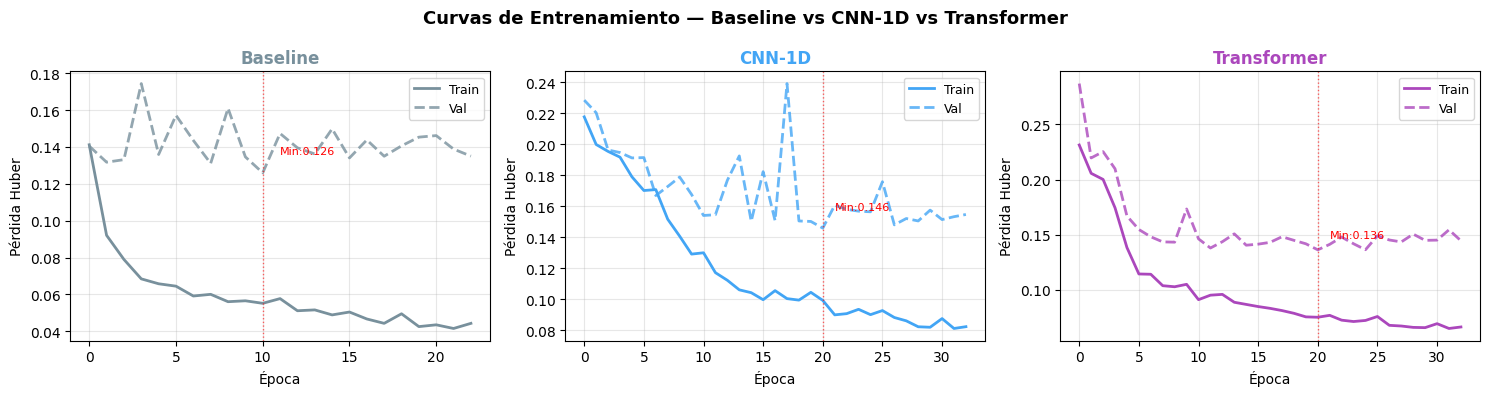

In [103]:
COLORS = {'Baseline': '#78909C', 'CNN-1D': '#42A5F5', 'Transformer': '#AB47BC'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Entrenamiento — Baseline vs CNN-1D vs Transformer',
             fontsize=13, fontweight='bold')

for ax, (name, hist) in zip(axes, histories.items()):
    c = COLORS[name]
    ax.plot(hist['train_loss'], color=c, lw=2, label='Train')
    ax.plot(hist['val_loss'],   color=c, lw=2, ls='--', alpha=0.8, label='Val')
    ax.set_title(name, fontweight='bold', color=c)
    ax.set_xlabel('Época'); ax.set_ylabel('Pérdida Huber')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    bi = np.argmin(hist['val_loss'])
    ax.axvline(bi, color='red', lw=1, ls=':', alpha=0.6)
    ax.annotate(f'Min:{hist["val_loss"][bi]:.3f}',
                xy=(bi, hist['val_loss'][bi]),
                xytext=(bi+1, hist['val_loss'][bi]*1.08),
                fontsize=8, color='red')

plt.tight_layout(); plt.show()

In [104]:
def evaluate_model(model, loader, name):
    model.eval().to(DEVICE)
    preds_sc, truths_sc = [], []
    with torch.no_grad():
        for xn_b, xc_b, y_b in loader:
            xn_b, xc_b = xn_b.to(DEVICE), xc_b.to(DEVICE)
            preds_sc.append(model(xn_b, xc_b).cpu().numpy())
            truths_sc.append(y_b.numpy())

    preds_log  = scaler_y.inverse_transform(
        np.concatenate(preds_sc).reshape(-1, 1)).ravel()
    truths_log = scaler_y.inverse_transform(
        np.concatenate(truths_sc).reshape(-1, 1)).ravel()

    preds  = np.clip(np.expm1(preds_log),  0, None)
    truths = np.expm1(truths_log)

    rmse  = np.sqrt(mean_squared_error(truths, preds))
    mae   = mean_absolute_error(truths, preds)
    r2    = r2_score(truths, preds)
    mask  = truths > 0
    mape  = np.mean(np.abs((truths[mask] - preds[mask]) / truths[mask])) * 100
    rmsle = np.sqrt(mean_squared_error(
        np.log1p(np.clip(truths, 0, None)),
        np.log1p(np.clip(preds,  0, None))))

    return {
        'Model': name, 'RMSLE': rmsle, 'RMSE': rmse,
        'MAE': mae, 'R²': r2, 'MAPE(%)': mape,
        'preds': preds, 'truths': truths
    }


### Evaluación de métricas

In [105]:
results = {}
for name, model in [
    ('Baseline', baseline),
    ('CNN-1D', cnn_model),
    ('Transformer', transformer)
]:
    results[name] = evaluate_model(model, test_loader, name)

df_res = pd.DataFrame([{
    'Modelo':  v['Model'],
    'RMSLE':   round(v['RMSLE'],   4),
    'RMSE':    round(v['RMSE'],    2),
    'MAE':     round(v['MAE'],     2),
    'R²':      round(v['R²'],      4),
    'MAPE(%)': round(v['MAPE(%)'], 2)
} for v in results.values()]).sort_values('RMSLE').reset_index(drop=True)

print('\n' + '='*75)
print('    RESULTADOS EN PRUEBA — Baseline vs CNN-1D vs Transformer')
print('='*75)
print(df_res.to_string(index=False))



    RESULTADOS EN PRUEBA — Baseline vs CNN-1D vs Transformer
     Modelo  RMSLE     RMSE      MAE     R²  MAPE(%)
     CNN-1D 0.1260 36222.42 26585.69 0.5501     9.89
Transformer 0.1267 35676.79 24164.74 0.5635     8.68
   Baseline 0.1635 47805.10 30772.59 0.2163    12.31


### Predicciones

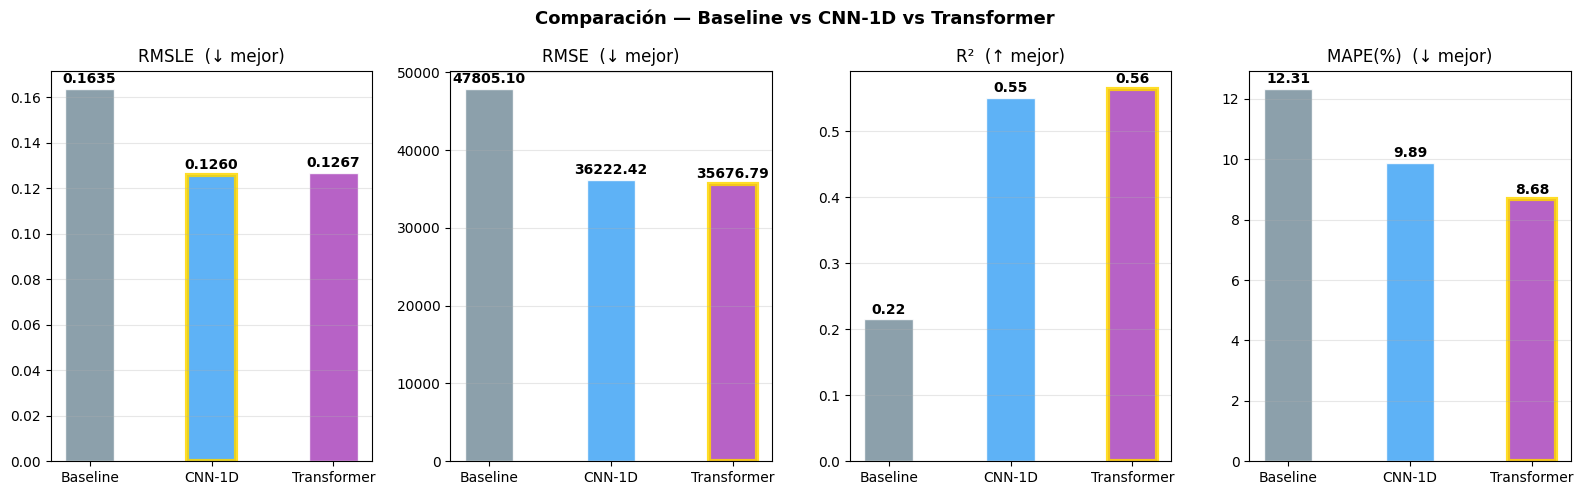

In [106]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Comparación — Baseline vs CNN-1D vs Transformer',
             fontsize=13, fontweight='bold')

mets    = [('RMSLE','lower'), ('RMSE','lower'), ('R²','higher'), ('MAPE(%)','lower')]
names_l = list(results.keys())
clrs    = [COLORS[n] for n in names_l]

for ax, (met, direction) in zip(axes, mets):
    vals = [results[n][met] for n in names_l]
    bars = ax.bar(names_l, vals, color=clrs, alpha=0.85, ec='white', width=0.4)
    bi   = np.argmin(vals) if direction == 'lower' else np.argmax(vals)
    bars[bi].set_edgecolor('gold'); bars[bi].set_linewidth(3)
    ax.set_title(f'{met}  ({"↓" if direction=="lower" else "↑"} mejor)')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                f'{v:.4f}' if met == 'RMSLE' else f'{v:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


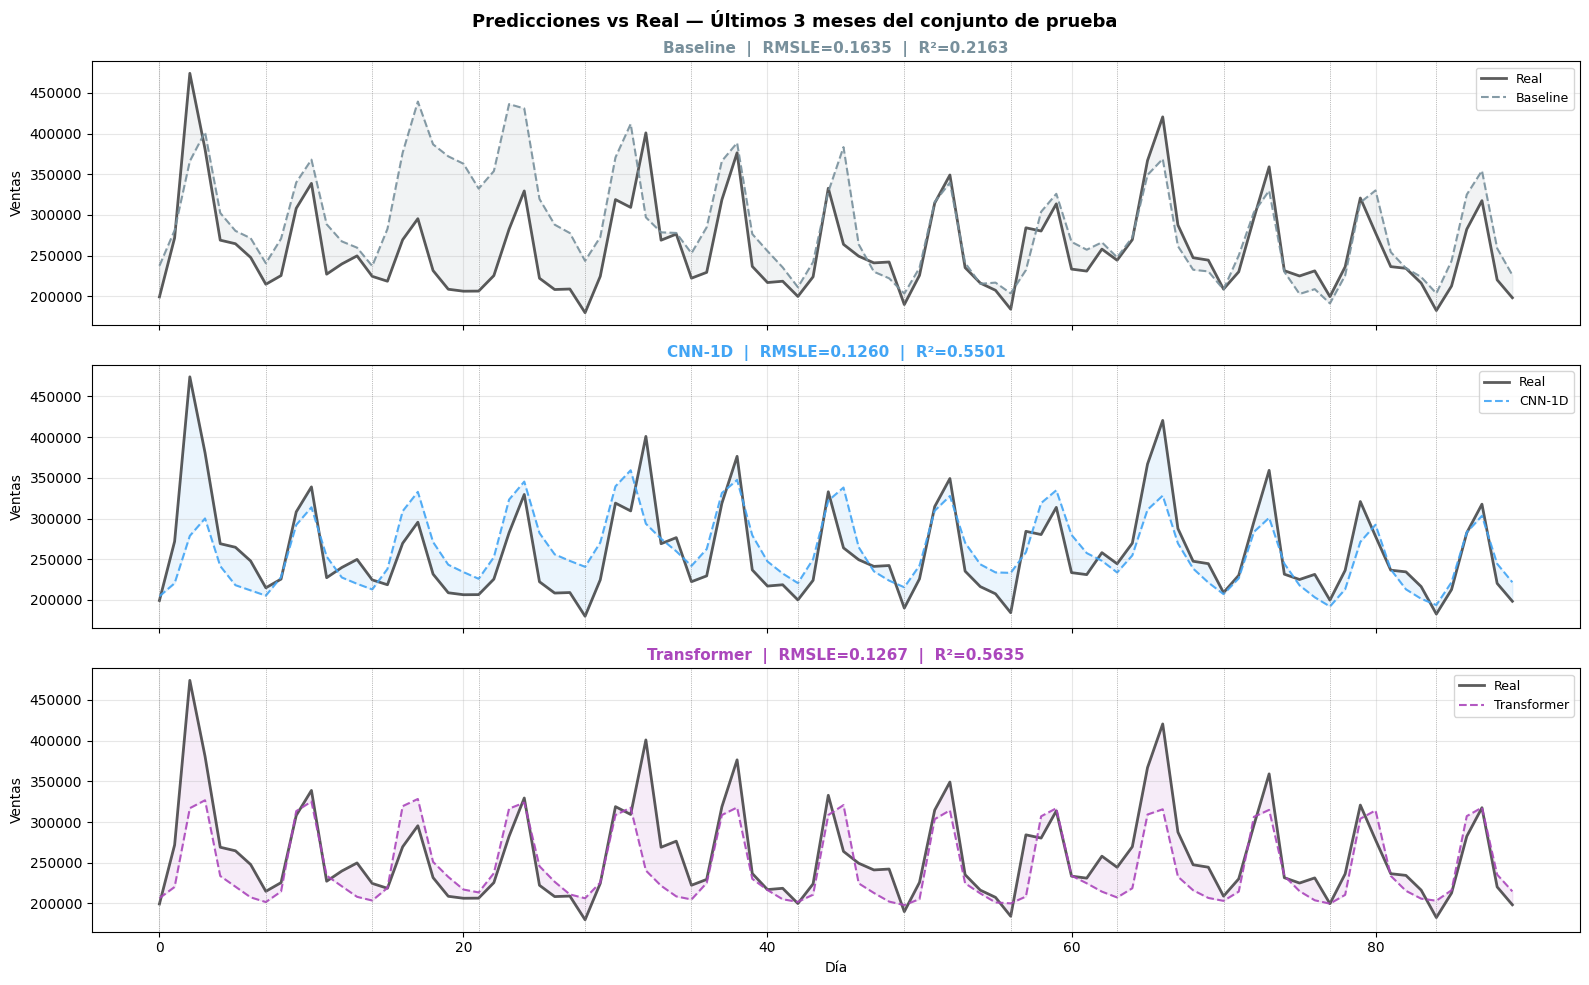

In [107]:
N_PLOT = 90
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Predicciones vs Real — Últimos 3 meses del conjunto de prueba',
             fontsize=13, fontweight='bold')

tr_ref = results['Baseline']['truths'][:N_PLOT]

for ax, (name, res) in zip(axes, results.items()):
    c = COLORS[name]
    ax.plot(tr_ref, color='#333', lw=2, alpha=0.8, label='Real')
    ax.plot(res['preds'][:N_PLOT], color=c, lw=1.5, ls='--', alpha=0.9, label=name)
    ax.fill_between(range(N_PLOT), tr_ref, res['preds'][:N_PLOT], alpha=0.1, color=c)
    ax.set_title(
        f'{name}  |  RMSLE={res["RMSLE"]:.4f}  |  R²={res["R²"]:.4f}',
        color=c, fontweight='bold', fontsize=11)
    ax.set_ylabel('Ventas')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    for d in range(0, N_PLOT, 7):
        ax.axvline(d, color='gray', lw=0.5, ls=':')

axes[-1].set_xlabel('Día')
plt.tight_layout(); plt.show()


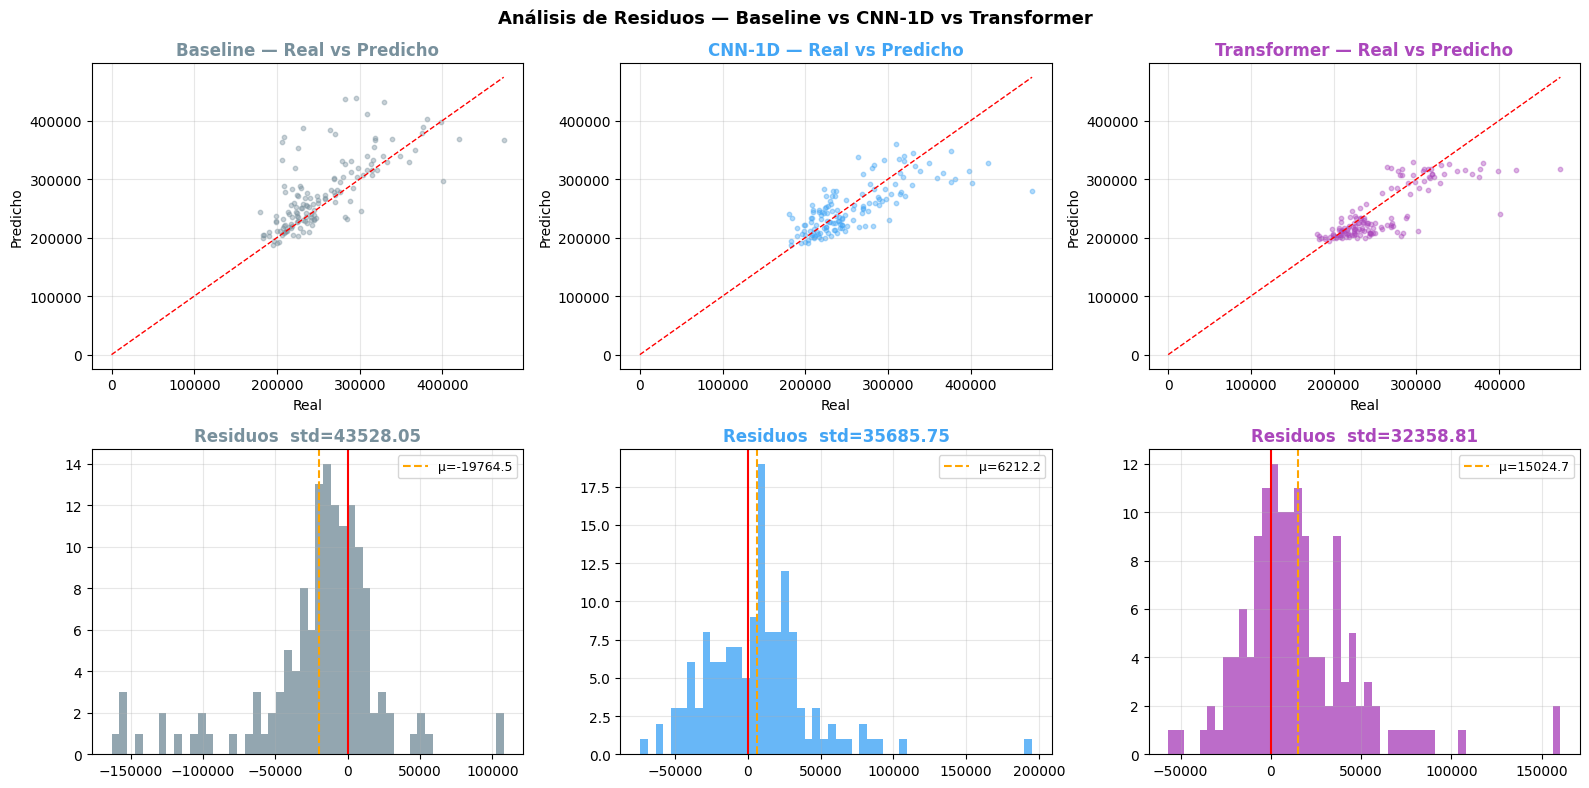


✅ Baseline, CNN-1D y Transformer entrenados y evaluados correctamente.


In [108]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Análisis de Residuos — Baseline vs CNN-1D vs Transformer',
             fontsize=13, fontweight='bold')

for col, (name, res) in enumerate(results.items()):
    c   = COLORS[name]
    err = res['truths'] - res['preds']
    lim = max(res['truths'].max(), res['preds'].max())

    axes[0,col].scatter(res['truths'], res['preds'], alpha=0.4, s=10, color=c)
    axes[0,col].plot([0, lim], [0, lim], 'r--', lw=1)
    axes[0,col].set_xlabel('Real'); axes[0,col].set_ylabel('Predicho')
    axes[0,col].set_title(f'{name} — Real vs Predicho', color=c, fontweight='bold')
    axes[0,col].grid(True, alpha=0.3)

    axes[1,col].hist(err, bins=50, color=c, alpha=0.8, ec='white')
    axes[1,col].axvline(0, color='red', lw=1.5)
    axes[1,col].axvline(err.mean(), color='orange', lw=1.5, ls='--',
                        label=f'μ={err.mean():.1f}')
    axes[1,col].set_title(f'Residuos  std={err.std():.2f}', color=c, fontweight='bold')
    axes[1,col].legend(fontsize=9); axes[1,col].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\n✅ Baseline, CNN-1D y Transformer entrenados y evaluados correctamente.')